In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "3"

In [2]:
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import pickle
import math
import scipy
from pathlib import Path
import sys
import os
import warnings
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from matplotlib.ticker import ScalarFormatter
from copy import deepcopy
sys.path.append("../src")
from custom_distance import KL, conditionKL
import itertools
import pickle

from utils import number_split, create_mix, appendMetrics
from data_process import load_wls_adress_AddDomain
from process_SHAC import load_process_SHAC
from custom_distance import KL
from process_HateSpeech import load_HateSpeech_dynGen, load_HateSpeech_wsf
from process_CD import load_cd

import random
from tqdm import tqdm

warnings.filterwarnings("ignore")


from augmentation import reverseTranslationDF

import json
import requests

from tqdm import tqdm

In [3]:
from torch import nn

In [4]:
sys.path.append("../src")
sys.path.append("../config")

from sampling_numbers import HateSpeech_DICT, SHAC_DICT, CD_DICT


# Load Data

In [5]:
dataset_name = "CD"
# dataset_name = "HateSpeech"
# dataset_name = "SHAC"

In [6]:

######## Load Data
if dataset_name == "SHAC":
    df_shac = load_process_SHAC(replaceNA="all")
    df_shac["label_binary"] = df_shac.apply(lambda x: 1 if x["Drug"] else 0, axis=1)
    df_shac["dfSource"] = df_shac["location"]

    df_shac_uw = df_shac.query("location == 'uw'").reset_index(drop=True)
    df_shac_mimic = df_shac.query("location == 'mimic'").reset_index(drop=True)

    n_test = 200
    
    z_Categories = ["uw", "mimic"]  # the order here matters! Should match with df0, df1
    label = "Drug"
    n_zCats = len(z_Categories)
    txt_col = "text"
    domain_col = "location"
    df0 = df_shac_uw
    df1 = df_shac_mimic
    
    df_split_label = "Drug"
elif dataset_name == "HateSpeech":
    df_dynGen = load_HateSpeech_dynGen()
    df_wsf = load_HateSpeech_wsf()

    # n_test = 1000
    n_test = 200
    
    z_Categories = [
        "dynGen",
        "wsf",
    ]  # the order here matters! Should match with df0, df1
    label = "label_binary"
    n_zCats = len(z_Categories)
    txt_col = "text"
    domain_col = "dfSource"
    df0 = df_dynGen
    df1 = df_wsf
    
    df_split_label = "label_binary"

elif dataset_name == "CD":
    df_all = load_cd()
    df_avh = df_all["avh"]
    df_r56 = df_all["r56"]

    n_test = 200
    
    z_Categories = ["avh", "r56"]
    label = "label_binary"
    n_zCats = len(z_Categories)
    txt_col = "text"
    domain_col = "dfSource"
    df0 = df_avh
    df1 = df_r56
    
    df_split_label = "label_binary"
    
    
    
# label = "label_llm_original"

In [7]:
df0['ssid'] = ["df0_" + str(x) for x in np.arange(len(df0))]
df1['ssid'] = ["df1_" + str(x) for x in np.arange(len(df1))]

## Train

In [10]:
### For CD and HateSpeech
# CombinationIdx = 566
CombinationIdx = 3636
# CombinationIdx = 6621
c = CD_DICT[f"c_n{n_test}_{CombinationIdx}"]

### For SHAC
# CombinationIdx = 1152
# CombinationIdx = 11063
# c = SHAC_DICT[f"c_n{n_test}_{CombinationIdx}"]


In [11]:
dfs = create_mix(
    df0=df0,
    df1=df1,
    target=df_split_label,
    setting=c,
    sample=False,
    # seed=random.randint(0,1000),
    seed=222,
)

In [12]:
## For Classify LLM vs Original

label = "label_llm_original"

dfs["train"][label] = 0

df_llm = pd.read_csv("../output/LLM_Generate/CD/expanded/sub-n_200-set_3636.csv")
df_llm = df_llm.drop([txt_col], axis=1).rename(columns={"LLM_Generate": txt_col})

df_llm[label] = 1

## Load Test

In [13]:
### For CD and HateSpeech
CombinationIdx = 566
# CombinationIdx = 3636
# CombinationIdx = 6621
c = CD_DICT[f"c_n{n_test}_{CombinationIdx}"]

### For SHAC
# CombinationIdx = 1152
# CombinationIdx = 11063
# c = SHAC_DICT[f"c_n{n_test}_{CombinationIdx}"]


In [14]:
dfs_test = create_mix(
    df0=df0,
    df1=df1,
    target=df_split_label,
    setting=c,
    sample=False,
    # seed=random.randint(0,1000),
    seed=222,
)

In [15]:
### For CD and HateSpeech
# CombinationIdx = 566
# CombinationIdx = 3636
CombinationIdx = 6621
c = CD_DICT[f"c_n{n_test}_{CombinationIdx}"]

### For SHAC
# CombinationIdx = 1152
# CombinationIdx = 11063
# c = SHAC_DICT[f"c_n{n_test}_{CombinationIdx}"]


In [16]:
dfs_test2 = create_mix(
    df0=df0,
    df1=df1,
    target=df_split_label,
    setting=c,
    sample=False,
    # seed=random.randint(0,1000),
    seed=222,
)

In [17]:
### For Classify LLM vs Original
dfs_test["train"][label] = 0
dfs_test2["train"][label] = 0

In [18]:
df_llm_test= pd.read_csv("../output/LLM_Generate/CD/expanded/sub-n_200-set_566.csv")
df_llm_test = df_llm_test.drop([txt_col], axis=1).rename(columns={"LLM_Generate": txt_col})


### For Classify LLM vs Original
df_llm_test[label] = 1

In [19]:
df_llm_test.groupby(label).size()

label_llm_original
1    7300
dtype: int64

# Setup Model

In [20]:

class train_config:
    def __init__(self):
        self.quantization: bool = False


globalconfig = train_config()
globalconfig.model_name = 'roberta-base'
globalconfig.max_seq_length = 512


globalconfig.lr = 1e-4
globalconfig.weight_decay = 1e-2
globalconfig.num_train_epochs = 20

globalconfig.momentum = 0.9

globalconfig.device = "cuda"



globalconfig.warmup_ratio = 0.1
globalconfig.profiler = False
globalconfig.device = "cuda"
globalconfig.per_device_train_batch_size = 32
globalconfig.per_device_eval_batch_size = 32


In [21]:
from transformers import (
    Trainer,
    TrainingArguments,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainerCallback,
    default_data_collator,
)
import datasets
from torch.utils.data import Dataset, DataLoader

In [22]:
class TextDataset(Dataset):
    def __init__(self, df_in, txt_col, label_col, domain_col, tokenizer, max_length):
        self.primary_label = df_in[label_col]
        self.domain_label = df_in[domain_col]
        self.text = df_in[txt_col]
        self.tokenized = tokenizer(list(df_in[txt_col]), return_tensors="pt", max_length=max_length, padding="max_length", truncation=True)

        self.tokenizer_keys = self.tokenized.keys()
        
    def __len__(self):
        return len(self.primary_label)
    
    def __getitem__(self, idx):
        primary_label = self.primary_label[idx]
        domain_label = self.domain_label[idx]
        text = self.text[idx]
        # input_ids = self.tokenized['input_ids'][idx]
        
        sample = {"Text": text, "primary_label": primary_label, "domain_label": domain_label}
        for key in self.tokenizer_keys:
            sample[key] = self.tokenized[key][idx]
        
        
        return sample

In [23]:
tokenizer = AutoTokenizer.from_pretrained(globalconfig.model_name, use_fast=False)


In [24]:
##### Dataset Loader and Tokenizer
def preprocess_function(examples):
    # tokenize
    ret = tokenizer(
        examples[txt_col],
        return_tensors="pt",
        max_length=globalconfig.max_seq_length,
        padding="max_length",
        truncation=True,
    ).to(globalconfig.device)

    return ret


def datasets_loader(df):
    # from pandas df to Dataset & tokenize
    ret_datasets = datasets.Dataset.from_pandas(
        df[[txt_col, "dfSource", label]]
        .rename(columns={label: "label"})
        .reset_index(drop=True)
    )
    ret_tokenized = ret_datasets.map(preprocess_function, batched=True)

    return ret_tokenized


In [26]:
## For Classify LLM vs Original
df_train = pd.concat([dfs["train"], df_llm.sample(800)]).dropna(subset=[txt_col], how='any').reset_index(drop=True)
df_test = pd.concat([dfs_test["train"], dfs_test2["train"], df_llm_test.sample(1600)]).dropna(subset=[txt_col], how='any')
df_test = df_test[~df_test['ssid'].isin(df_train)].reset_index(drop=True)

print(df_test[~df_test['ssid'].isin(df_train)].groupby(['label_llm_original']).size())

print(df_train.groupby(['label_llm_original']).size())

label_llm_original
0    1600
1    1600
dtype: int64
label_llm_original
0    800
1    799
dtype: int64


In [27]:
# # For Classify Original Label
# df_train = pd.concat([dfs["train"]]).dropna(subset=[txt_col], how='any').reset_index(drop=True)
# df_test = pd.concat([ df_llm_test]).dropna(subset=[txt_col], how='any')
# df_test = df_test[~df_test['ssid'].isin(df_train)].reset_index(drop=True)

In [27]:
tokenized_train = datasets_loader(df_train)
tokenized_test = datasets_loader(df_test)

Map:   0%|          | 0/1599 [00:00<?, ? examples/s]

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

In [28]:
import torch

In [29]:
from transformers import AutoModelForSequenceClassification

In [30]:
model = AutoModelForSequenceClassification.from_pretrained(globalconfig.model_name, num_labels=2)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.dense.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [31]:
model.to(globalconfig.device)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [32]:
config = {
    "learning_rate": globalconfig.lr,
    "num_train_epochs": globalconfig.num_train_epochs,
    "gradient_accumulation_steps": 2,
    "per_device_train_batch_size": globalconfig.per_device_train_batch_size,
    "per_device_eval_batch_size": globalconfig.per_device_eval_batch_size,
    "gradient_checkpointing": False,
    "warmup_ratio": globalconfig.warmup_ratio,
}

In [33]:
output_dir = "../output/Classify_LLM_Original"

In [34]:
from sklearn.metrics import average_precision_score

def compute_metrics_twoLevels(eval_pred):
    # compute AUPRC, based on only two levels of Y
    predictions, labels = eval_pred
    probabilities = nn.functional.softmax(torch.FloatTensor(predictions), dim=-1)[:, 1]

    auprc = average_precision_score(y_true=labels, y_score=probabilities)

    return {"auprc": auprc}



In [35]:
training_args = TrainingArguments(
    output_dir=output_dir,
    overwrite_output_dir=True,
    logging_dir=f"{output_dir}/logs",
    logging_strategy="steps",
    logging_steps=10,
    save_strategy="no",
    optim="adamw_torch",
    # max_steps=total_steps if enable_profiler else -1,
    load_best_model_at_end=True,

    **{k: v for k, v in config.items()},
)

In [36]:
trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        data_collator=default_data_collator,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics_twoLevels,
        # callbacks=[profiler_callback] if enable_profiler else [],
    )

# Start training
ret_train = trainer.train()
# ret_eval = trainer.evaluate()

Step,Training Loss
10,0.691200
20,0.669400
30,0.470100
40,0.305700
50,0.275100
60,0.298500
70,0.197300
80,0.122400
90,0.134500
100,0.152600


In [37]:
predicted = trainer.predict(test_dataset=tokenized_test)

In [38]:
predicted

PredictionOutput(predictions=array([[ 5.056651 , -4.8671575],
       [ 5.0325775, -4.8129983],
       [ 5.0540175, -4.8669963],
       ...,
       [-4.694451 ,  4.7693963],
       [-4.7023606,  4.785826 ],
       [-4.70414  ,  4.7819495]], dtype=float32), label_ids=array([0, 0, 0, ..., 1, 1, 1]), metrics={'test_loss': 0.24063044786453247, 'test_auprc': 0.9929082969847702, 'test_runtime': 23.5533, 'test_samples_per_second': 135.862, 'test_steps_per_second': 4.246})

In [39]:
sfmax = nn.Softmax(dim=1)


In [40]:
predicted.predictions

array([[ 5.056651 , -4.8671575],
       [ 5.0325775, -4.8129983],
       [ 5.0540175, -4.8669963],
       ...,
       [-4.694451 ,  4.7693963],
       [-4.7023606,  4.785826 ],
       [-4.70414  ,  4.7819495]], dtype=float32)

In [41]:
probs = sfmax(torch.tensor(predicted.predictions))

In [42]:
probs

tensor([[9.9995e-01, 4.8992e-05],
        [9.9995e-01, 5.2978e-05],
        [9.9995e-01, 4.9129e-05],
        ...,
        [7.7601e-05, 9.9992e-01],
        [7.5736e-05, 9.9992e-01],
        [7.5895e-05, 9.9992e-01]])

In [43]:
probs.mean(0)

tensor([0.5132, 0.4868])

In [44]:
probs.shape

torch.Size([3200, 2])

In [45]:
len(tokenized_test['label'])

3200

# Plot

In [46]:
sns.reset_defaults()
sns.set_theme(style="ticks", rc={"figure.dpi": 350})


In [47]:
import matplotlib.pyplot as plt

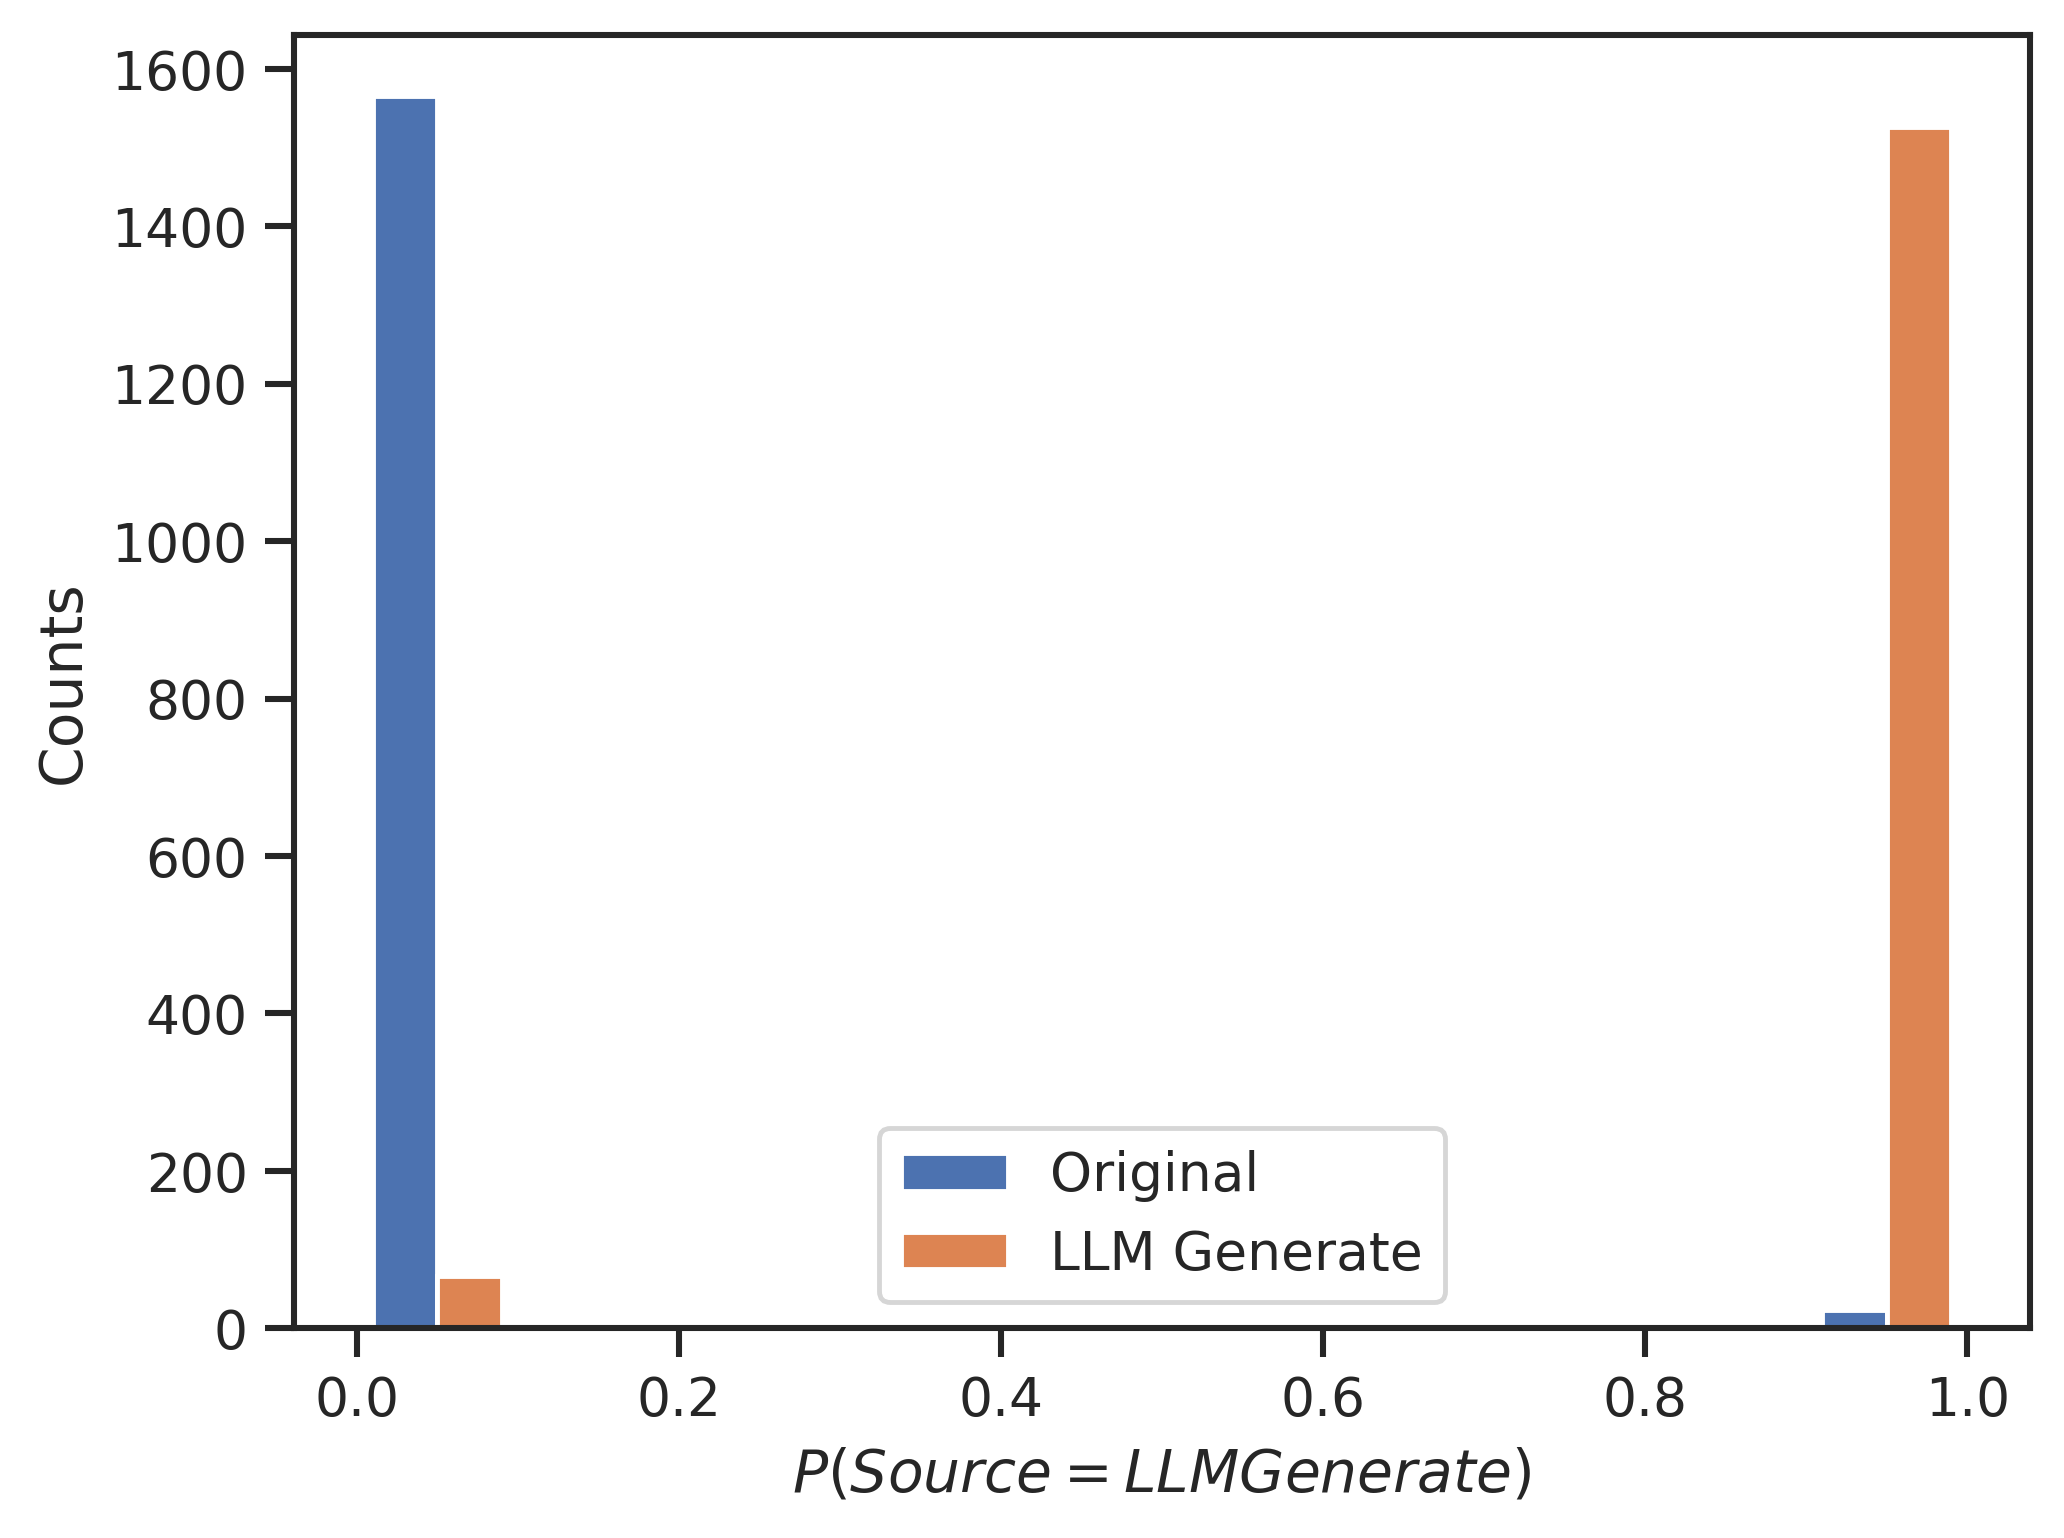

In [48]:
plt.hist([probs[np.array(tokenized_test["label"]) == 0,1], probs[np.array(tokenized_test["label"]) == 1,1]], label=['Original','LLM Generate'])
plt.xlabel(r"$P(Source=LLM Generate)$")
plt.ylabel("Counts")
plt.legend()
plt.show()

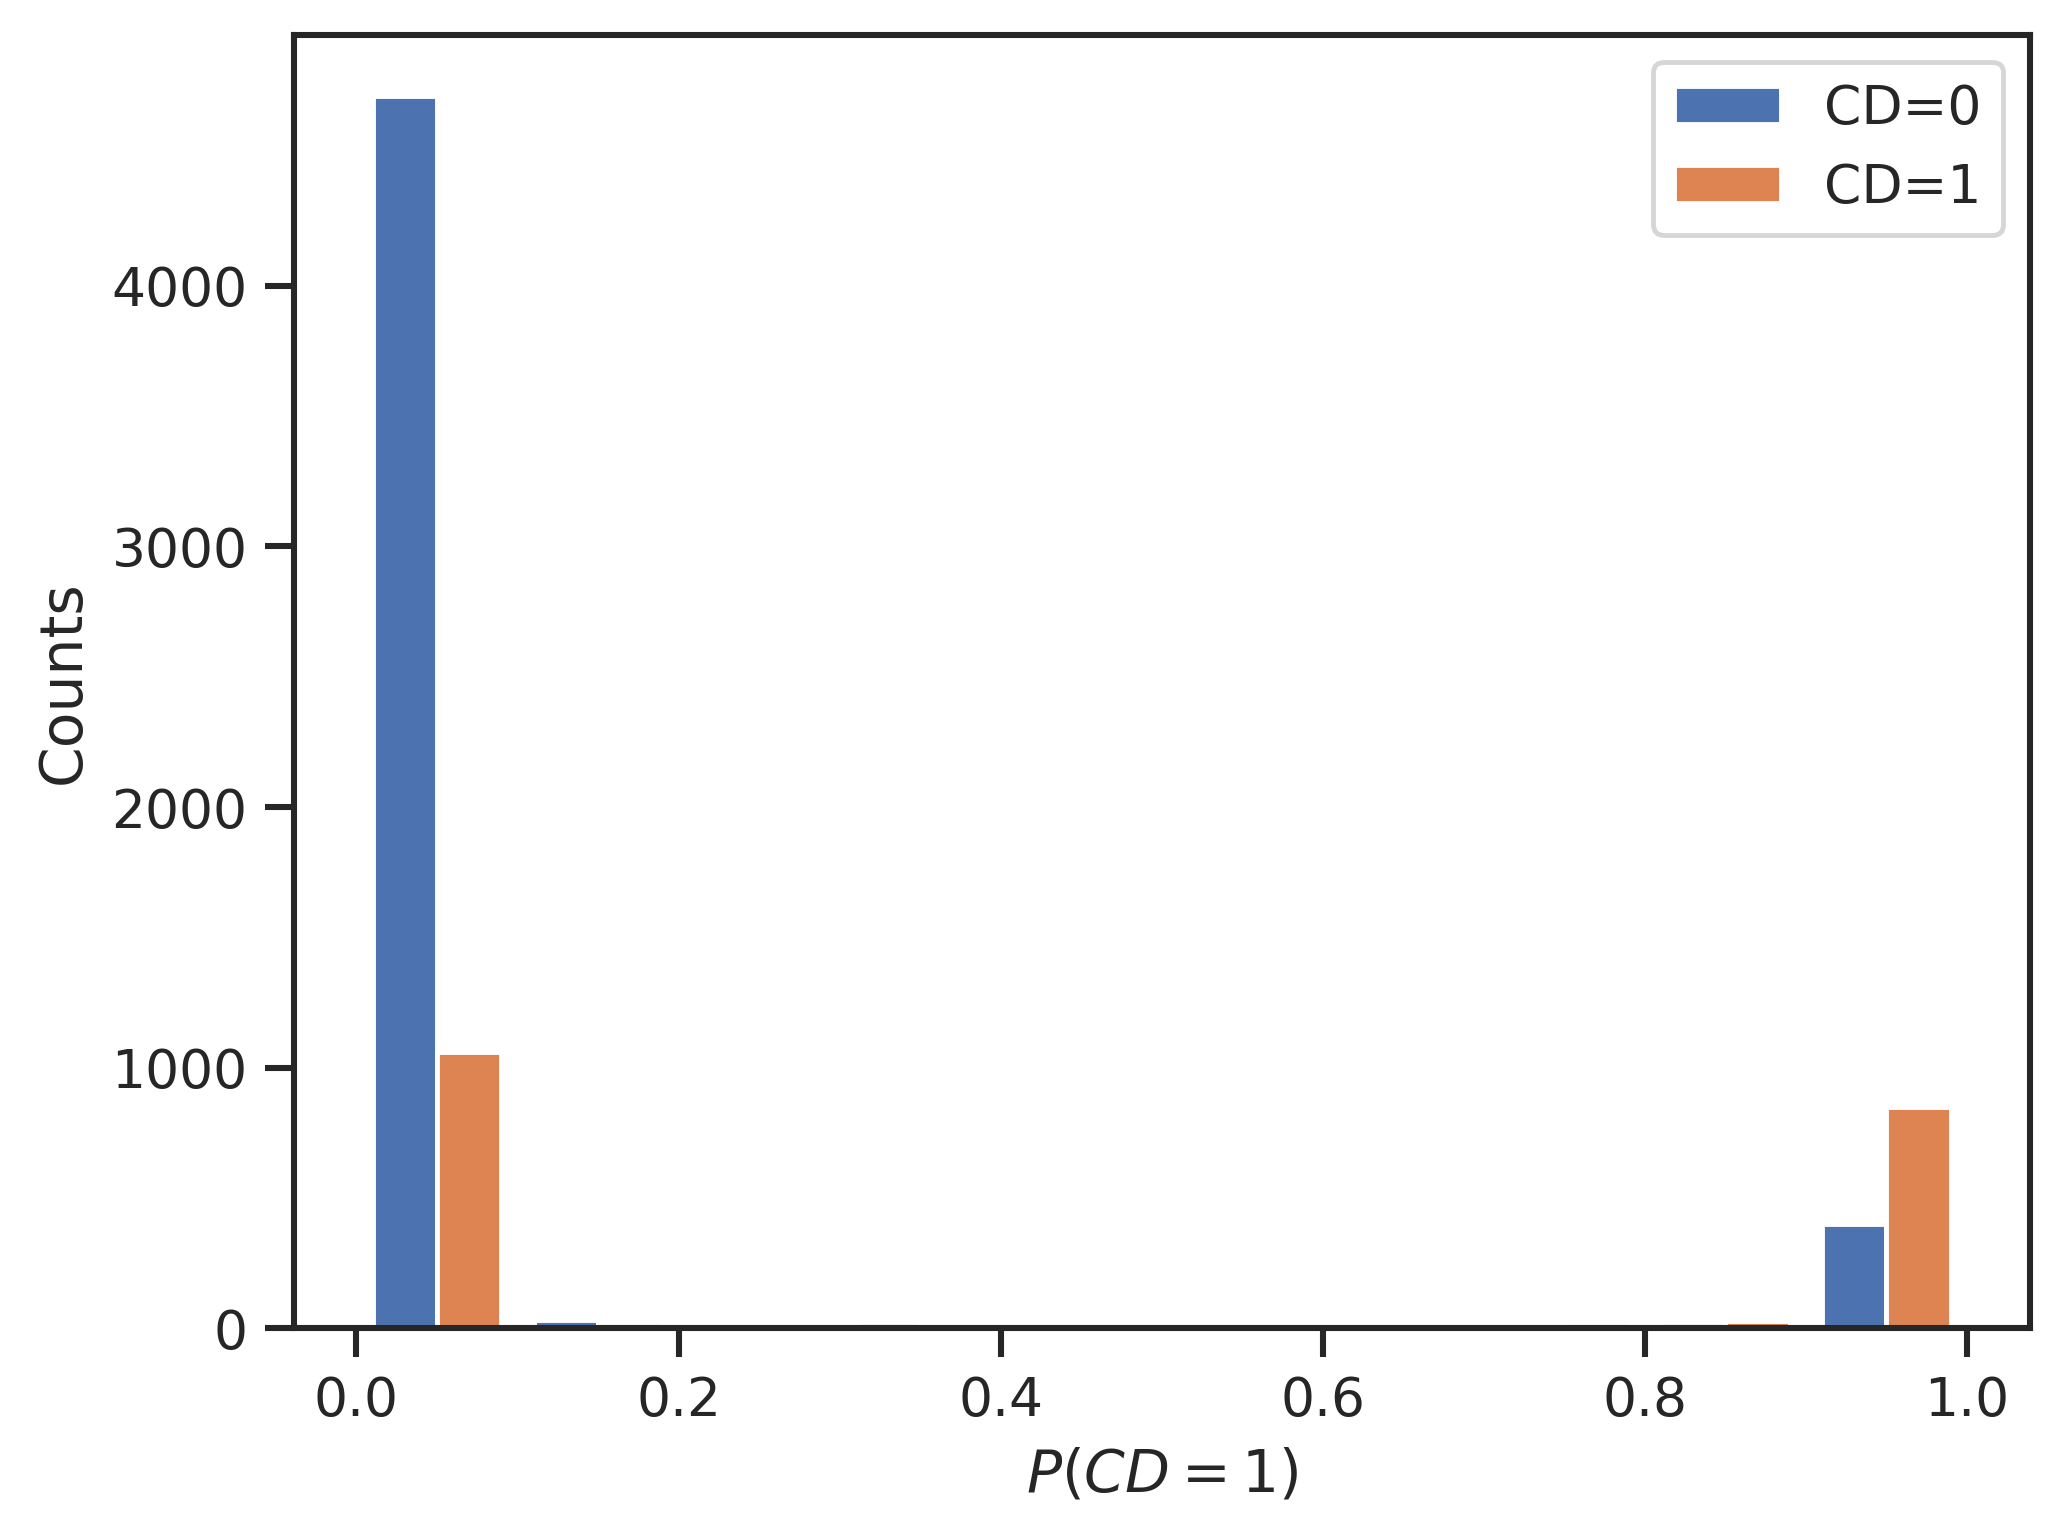

In [62]:
plt.hist([probs[np.array(tokenized_test["label"]) == 0,1], probs[np.array(tokenized_test["label"]) == 1,1]], label=['CD=0','CD=1'])
plt.xlabel(r"$P(CD=1)$")
plt.ylabel("Counts")
plt.legend()
plt.show()

In [50]:
# For Classify Original Label
# df_train = pd.concat([dfs["train"]]).dropna(subset=[txt_col], how='any').reset_index(drop=True)
df_test = pd.concat([ dfs_test["train"], dfs_test2["train"]]).dropna(subset=[txt_col], how='any')
df_test = df_test[~df_test['ssid'].isin(df_train)].reset_index(drop=True)

In [51]:
tokenized_test2 = datasets_loader(df_test)

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

In [52]:
predicted2 = trainer.predict(test_dataset=tokenized_test2)

In [53]:
probs2 = sfmax(torch.tensor(predicted2.predictions))

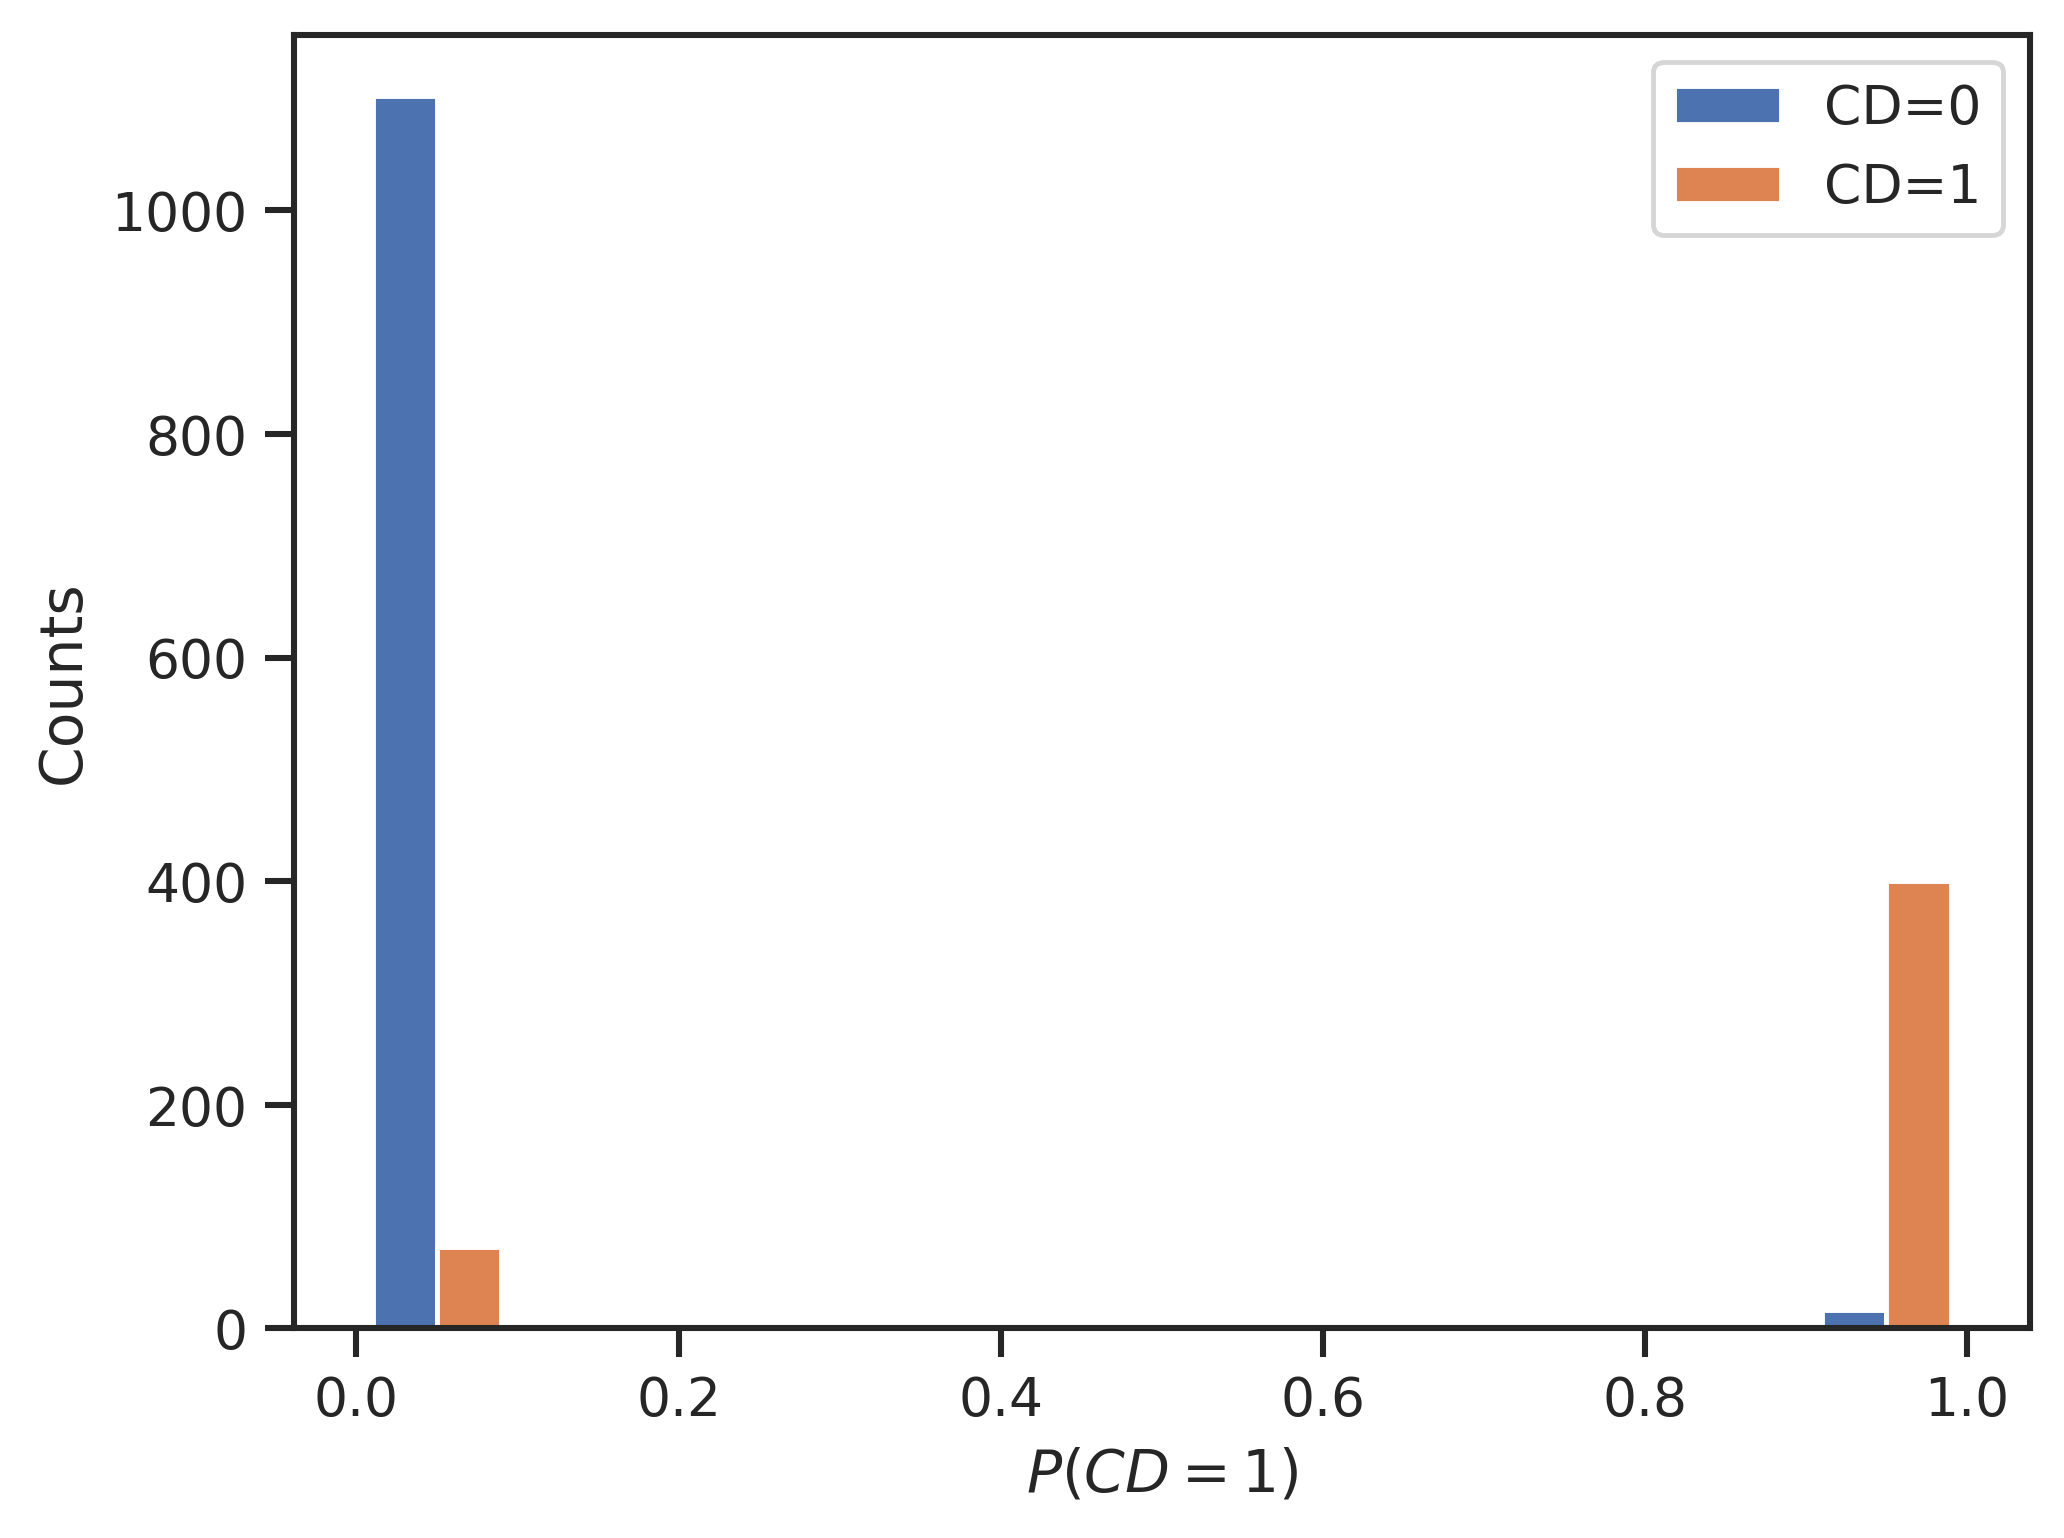

In [63]:
plt.hist([probs2[np.array(tokenized_test2["label"]) == 0,1], probs2[np.array(tokenized_test2["label"]) == 1,1]], label=['CD=0','CD=1'])
plt.xlabel(r"$P(CD=1)$")
plt.ylabel("Counts")
plt.legend()
plt.show()